
# 📘 Análisis de Datos Cualitativos con Python e IA
### Teoría, metodologías, aplicación práctica y validación con datos de prueba

**Contexto:** NovaRetail — análisis de comentarios de encuestas de satisfacción

---

**Qué encontrarás en este notebook:**

1. Marco teórico: qué es el análisis cualitativo y cómo se diferencia del cuantitativo.
2. Las principales metodologías de análisis cualitativo (clásicas y computacionales).
3. Cuándo usar cada una, bajo qué supuestos, y con qué limitaciones.
4. Un dataset **sintético** de prueba (texto libre generado, no son clientes reales) para validar cada técnica.
5. Implementación paso a paso en Python de cada metodología.
6. Una sección específica sobre **cómo y bajo qué supuestos usar IA (LLMs)** como apoyo al análisis cualitativo.
7. Validación: comparamos lo que las técnicas "descubren" contra la estructura temática real con la que se generaron los datos.

> ⚠️ **Nota sobre los datos:** el archivo `datos_cualitativos_prueba.csv` es **sintético**: los comentarios fueron generados combinatoriamente a partir de plantillas para efectos pedagógicos. No representan clientes reales de NovaRetail. La columna `tema_real_sintetico` es un "answer key" que normalmente **no existe** en datos reales — aquí se incluye únicamente para poder *validar* qué tan bien funciona cada técnica.


## ▶️ Cómo usar este notebook en Google Colab

Este laboratorio está preparado para ejecutarse **sin instalación local de Python**.

1. Abre el archivo `.ipynb` en Google Colab.
2. Ejecuta las celdas de arriba hacia abajo.
3. En la celda de carga, selecciona `datos_cualitativos_prueba.csv` desde tu computador.
4. Las técnicas principales funcionan sin API de pago.
5. La sección de LLM está diseñada primero para **copiar un prompt a ChatGPT, Gemini o Claude**; la API queda como extensión opcional.

> **Objetivo docente:** el código está preparado para copiar/ejecutar. La clase se concentra en interpretar resultados, comparar metodologías y discutir supuestos.


In [ ]:
# Dependencias del laboratorio (Google Colab)
# La mayoría ya vienen instaladas; esta celda garantiza wordcloud y scikit-learn.
%pip -q install wordcloud scikit-learn



## 1. ¿Qué es el análisis de datos cualitativos?

El **análisis cualitativo** es el conjunto de métodos utilizados para examinar datos **no numéricos** — texto, audio, video, imágenes, observaciones — con el fin de comprender significados, patrones, motivaciones y experiencias que no se capturan directamente con números.

### 1.1 Diferencia con el análisis cuantitativo

| Aspecto | Análisis cuantitativo | Análisis cualitativo |
|---|---|---|
| Tipo de dato | Numérico, estructurado | Texto, no estructurado |
| Pregunta típica | ¿Cuánto? ¿Cuántos? | ¿Por qué? ¿Cómo? |
| Lógica | Deductiva (prueba hipótesis) | Frecuentemente inductiva (genera hipótesis) |
| Resultado | Estadísticas, magnitudes | Temas, categorías, narrativas |
| Ejemplo en NovaRetail | `calificacion`, `nps`, `valor_venta` | `comentario` de la encuesta |

**Importante:** ambos enfoques no son excluyentes. La práctica más robusta —y la que seguiremos en este notebook— es la **triangulación**: cruzar los hallazgos cualitativos (temas, sentimiento) con las variables cuantitativas (`calificacion`, `nps`) para validar si lo que dice el texto es consistente con lo que dicen los números.

### 1.2 ¿Por qué el análisis cualitativo es más difícil de automatizar?

- No hay un "promedio" de una oración.
- El significado depende del contexto, la ironía, la negación, la ambigüedad.
- Dos personas pueden codificar el mismo texto de forma distinta (esto se mide con el concepto de **confiabilidad entre codificadores** o *inter-rater reliability*).
- La automatización (NLP/IA) puede **acelerar** el proceso, pero rara vez sustituye por completo el juicio humano — especialmente en la interpretación final.



## 2. Metodologías clásicas de análisis cualitativo

Estas son las metodologías desarrolladas originalmente por la investigación social y que **preceden** al uso de computadoras. Todas las herramientas computacionales que veremos después (Sección 4) son, en el fondo, formas de acelerar o escalar estos procesos.

---

### 2.1 Análisis de contenido (*Content Analysis*)

**Qué es:** cuantifica la presencia de categorías predefinidas dentro de un texto. Es la metodología más **deductiva**: se parte de un esquema de categorías (codebook) definido *antes* de leer los datos.

**Procedimiento típico:**
1. Definir categorías de interés (ej. "queja por entrega", "elogio al producto").
2. Leer cada unidad de texto y asignarle una o más categorías.
3. Contar frecuencias por categoría.
4. Analizar relaciones entre categorías y variables numéricas.

**Supuestos:** existe un esquema de categorías razonablemente estable y conocido de antemano. Funciona mejor cuando ya se sabe *qué se está buscando*.

**Cuándo usarlo:** cuando ya tienes hipótesis claras (ej. "sospechamos que las quejas se concentran en tiempos de entrega") y quieres cuantificar cuánto texto corresponde a cada una.

---

### 2.2 Análisis temático (*Thematic Analysis* — Braun & Clarke, 2006)

**Qué es:** identifica, analiza y reporta patrones (temas) dentro de los datos, con un enfoque más **inductivo** que el análisis de contenido (aunque también puede aplicarse de forma deductiva).

**Las 6 fases de Braun & Clarke:**

| Fase | Qué se hace |
|---|---|
| 1. Familiarización | Leer y releer los datos varias veces |
| 2. Generación de códigos iniciales | Etiquetar segmentos relevantes de texto |
| 3. Búsqueda de temas | Agrupar códigos relacionados en temas candidatos |
| 4. Revisión de temas | Verificar que los temas sean coherentes y distintos entre sí |
| 5. Definición y nombramiento | Escribir una definición clara de cada tema |
| 6. Elaboración del reporte | Presentar los temas con evidencia textual |

Esto es exactamente lo que hicimos manualmente en el ejercicio anterior con `satisfaccion.csv`: leímos los comentarios, identificamos códigos (frases repetidas), los agrupamos en 5 temas, y documentamos evidencia textual y ambigüedades.

**Supuestos:** los temas "emergen" de los datos; el investigador debe mantener una postura reflexiva sobre sus propios sesgos al interpretar.

**Cuándo usarlo:** es el método más versátil y ampliamente usado en investigación aplicada y de negocio — recomendable como punto de partida por defecto.

---

### 2.3 Teoría fundamentada (*Grounded Theory* — Glaser & Strauss, 1967)

**Qué es:** un método sistemático para **construir teoría directamente desde los datos**, sin partir de una hipótesis previa. Es el enfoque más riguroso y el más inductivo.

**Etapas de codificación:**

1. **Codificación abierta (open coding):** se etiqueta línea por línea o segmento por segmento, generando muchos códigos de bajo nivel.
2. **Codificación axial (axial coding):** se relacionan los códigos entre sí, identificando categorías, propiedades y dimensiones.
3. **Codificación selectiva (selective coding):** se identifica una categoría central que integra a las demás, dando lugar a una teoría o modelo explicativo.

**Concepto clave — Saturación teórica:** se deja de recolectar/codificar datos nuevos cuando estos ya no aportan categorías o propiedades nuevas.

**Supuestos:** requiere iteración entre recolección y análisis (no es un proceso de una sola pasada); es exigente en tiempo y normalmente se aplica a conjuntos de datos más pequeños y ricos (entrevistas a profundidad) más que a miles de comentarios cortos.

**Cuándo usarlo:** cuando el objetivo es *generar una explicación causal o un modelo* (ej. "¿por qué los clientes abandonan después de una cancelación?"), no solo describir temas.

---

### 2.4 Análisis de discurso y análisis narrativo

**Análisis de discurso:** se enfoca en *cómo* se dice algo (el lenguaje, el poder, las relaciones sociales implícitas), no solo en *qué* se dice. Es más común en ciencias sociales y políticas que en analítica de negocio.

**Análisis narrativo:** analiza la *estructura* de una historia contada por el participante (inicio, conflicto, resolución). Útil en entrevistas largas o historias de cliente (*customer journeys*), poco práctico para comentarios cortos de encuestas.

**Cuándo usarlos:** rara vez son la primera opción en analítica de negocio; se mencionan aquí por completitud metodológica.

---

### 2.5 Análisis de redes de texto (*Text Network Analysis*)

**Qué es:** representa el texto como un grafo, donde las palabras/conceptos son nodos y sus co-ocurrencias son las relaciones (aristas). Permite visualizar qué conceptos están más "centrales" o conectan distintos temas.

**Supuestos:** funciona mejor con volúmenes de texto medianos a grandes y con vocabulario relativamente consistente.

**Cuándo usarlo:** cuando además de saber *qué* temas existen, interesa saber *cómo se relacionan* entre sí (ej. herramientas como InfraNodus).



## 3. Tabla comparativa: ¿cuál metodología usar?

| Metodología | Lógica | Tamaño de muestra ideal | Requiere esquema previo | Nivel de automatización posible |
|---|---|---|---|---|
| Análisis de contenido | Deductiva | Mediano-grande | Sí | Alto (con diccionario de reglas) |
| Análisis temático | Mixta (inductiva/deductiva) | Pequeño-mediano | No (o parcial) | Medio (asistido por IA/NLP) |
| Teoría fundamentada | Inductiva | Pequeño (rico en detalle) | No | Bajo-medio |
| Análisis de discurso/narrativo | Interpretativa | Pequeño | No | Bajo |
| Análisis de redes de texto | Exploratoria | Mediano-grande | No | Alto |
| **Métodos computacionales** (Sección 4) | Variable | Grande (cientos-miles) | Depende del método | Muy alto |

**Regla práctica:** a mayor volumen de texto, más conviene apoyarse en métodos computacionales — pero **siempre con validación humana** de una muestra de los resultados (esto se llama *"human-in-the-loop"*).



## 4. Métodos computacionales y de IA para apoyar el análisis cualitativo

Estos métodos no reemplazan las metodologías de la Sección 2 — son **formas de ejecutarlas a escala**. A continuación, el mapeo conceptual:

| Metodología clásica | Técnica computacional equivalente |
|---|---|
| Análisis de contenido (deductivo) | Diccionario de reglas / clasificación por palabras clave |
| Análisis temático (inductivo) | Modelado de tópicos (LDA, NMF, BERTopic) |
| Codificación abierta (Grounded Theory) | Clustering semántico con *embeddings* |
| Interpretación/resumen de temas | Modelos de lenguaje (LLMs) usados como asistentes |
| Polaridad emocional del texto | Análisis de sentimiento (basado en léxico o en modelos) |

### 4.1 Preprocesamiento de texto (NLP)

Paso obligatorio antes de cualquier técnica computacional:
- **Normalización:** minúsculas, remover tildes/puntuación si aplica.
- **Tokenización:** dividir el texto en palabras.
- **Eliminación de *stopwords*:** palabras muy frecuentes sin carga semántica ("el", "la", "de", "que"...).
- **Lematización/stemming (opcional):** reducir palabras a su raíz ("comprando" → "comprar").

**Supuesto crítico:** el preprocesamiento en español requiere recursos específicos del idioma (listas de stopwords, lematizadores) — usar herramientas en inglés sin adaptar produce resultados pobres.

### 4.2 Frecuencias y nubes de palabras

**Qué es:** cuenta cuántas veces aparece cada palabra (o n-grama) y lo representa visualmente.

**Ventaja:** rapidísimo, cero configuración, buen punto de partida exploratorio.

**Desventaja:** no captura contexto ni sentimiento — "no me gustó" y "me gustó" contribuyen igual a la palabra "gustó".

### 4.3 Análisis de sentimiento

**Enfoque basado en léxico:** se usa un diccionario de palabras positivas/negativas con un puntaje asociado; se suman los puntajes de las palabras presentes en el texto.
- Ventaja: transparente, explicable, no requiere entrenamiento ni conexión a internet.
- Desventaja: no entiende negaciones complejas, sarcasmo, ni jerga fuera del diccionario.

**Enfoque basado en modelos (Machine Learning / Transformers):** modelos entrenados (ej. BETO, RoBERTuito, pysentimiento en español) que predicen sentimiento a partir de patrones aprendidos.
- Ventaja: mejor manejo de contexto y ambigüedad.
- Desventaja: requiere descargar modelos preentrenados (conexión a internet), mayor costo computacional, y sigue pudiendo equivocarse — debe validarse contra una muestra etiquetada manualmente.

### 4.4 Modelado de tópicos (Topic Modeling)

**Qué es:** algoritmos no supervisados (LDA, NMF) que agrupan documentos en "tópicos" según qué palabras tienden a co-ocurrir.

**Supuestos clave:**
- Hay que **decidir de antemano** cuántos tópicos (`k`) se quieren — esto no lo determina el algoritmo por sí solo.
- Los tópicos resultantes no vienen "nombrados"; el analista debe interpretarlos y ponerles nombre (igual que en la fase 5 del análisis temático de Braun & Clarke).
- Funciona mejor con **texto libre y variado**; si el texto ya está semi-estructurado (pocas frases repetidas), el modelo aporta poco más que un conteo de frecuencias.

### 4.5 Clustering semántico con *embeddings*

**Qué es:** en vez de contar palabras, se convierte cada comentario en un vector numérico que captura su significado (*embedding*), y se agrupan los comentarios más similares semánticamente (ej. K-Means sobre embeddings, o herramientas como BERTopic).

**Ventaja sobre LDA:** puede agrupar comentarios que usan palabras distintas pero significan lo mismo (ej. "llegó tarde" y "hubo demora en el envío").

**Supuesto:** requiere un modelo de embeddings preentrenado (a menudo se descarga de internet); el costo computacional es mayor que con LDA/NMF.

### 4.6 Uso de LLMs (IA generativa) como asistentes de codificación cualitativa

Esta es la frontera más reciente. Un modelo de lenguaje (como Claude, GPT, etc.) puede ayudar a:

- Sugerir un *codebook* inicial de categorías a partir de una muestra de comentarios.
- Clasificar cada comentario en las categorías del codebook (codificación deductiva asistida).
- Generar resúmenes por tema.
- Redactar hipótesis o preguntas de investigación a partir de patrones detectados.
- Explicar o "traducir" resultados de LDA/embeddings a lenguaje natural interpretable.

**Contextos y supuestos importantes para usar IA generativa en análisis cualitativo (léase con atención):**

1. **No reemplaza la validación humana.** Un LLM puede alucinar categorías o mal-clasificar comentarios ambiguos; siempre se debe auditar una muestra de sus decisiones.
2. **Requiere acceso a una API** (ej. Anthropic, OpenAI) con las credenciales correspondientes — esto tiene costo y depende de conexión a internet, algo que no siempre está disponible en el entorno de análisis (por eso, en este notebook, la sección de LLM se muestra como **código ilustrativo**, no ejecutado).
3. **Privacidad de los datos:** enviar comentarios de clientes reales a una API externa puede tener implicaciones de privacidad/legal — debe evaluarse según la política de datos de la organización (anonimizar antes de enviar, usar un proveedor con acuerdo de tratamiento de datos, etc.).
4. **Sesgo y reproducibilidad:** los LLMs pueden dar resultados ligeramente distintos ante el mismo input en ejecuciones diferentes; para investigación rigurosa se recomienda fijar parámetros (temperatura baja) y documentar el prompt exacto usado.
5. **Es más útil como acelerador que como reemplazo:** el mejor flujo de trabajo suele ser *codificación asistida por IA + revisión humana de una muestra*, no automatización 100% desatendida.



---
## 5. Aplicación práctica: validando las metodologías con datos de prueba

A partir de aquí todo el código es **ejecutable**. Usaremos `datos_cualitativos_prueba.csv`, un dataset **sintético** de 2.000 comentarios de encuesta generados combinatoriamente (ver script `generar_dataset.py` incluido), que simula respuestas de clientes de NovaRetail con:

- `comentario`: texto libre (no plantillas fijas, a diferencia del ejercicio anterior).
- `calificacion` (1-5) y `nps` (0-10): variables numéricas para triangulación.
- `region`, `canal`, `categoria`: variables de segmentación.
- `tema_real_sintetico`: **la estructura temática real** usada para generar cada comentario. Esta columna normalmente **no existiría en datos reales** — aquí sirve exclusivamente para *validar* qué tan bien recupera cada técnica los temas reales.

### 5.1 Carga y exploración inicial


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_colwidth", 120)

archivo = Path("datos_cualitativos_prueba.csv")

# En Google Colab, si el CSV no está todavía en la sesión, se solicita cargarlo.
if not archivo.exists():
    try:
        from google.colab import files
        print("📁 Selecciona el archivo: datos_cualitativos_prueba.csv")
        uploaded = files.upload()
    except ImportError:
        print("No estás en Colab. Coloca el CSV en la misma carpeta del notebook.")

df = pd.read_csv("datos_cualitativos_prueba.csv", encoding="utf-8-sig")
print("Dimensiones:", df.shape)
display(df.head(5))

Dimensiones: (2000, 10)


,id_encuesta,id_cliente,fecha,region,canal,categoria,calificacion,nps,comentario,tema_real_sintetico
0,S0001,C174,2026-01-27,Caribe,App,Tecnología,1,5,"Tuve que cancelar mi pedido porque nunca llegó la confirmación de envío. Además, excelente atención al cliente, me a...",cancelacion_devolucion
1,S0002,C115,2026-02-26,Pacífica,Tienda,Hogar,4,10,"El producto llegó en excelente estado, la calidad superó mis expectativas. En general, la página se trabó varias vec...",calidad_producto
2,S0003,C024,2026-01-27,Orinoquía,Tienda,Cuidado personal,3,6,"Además, Todo llegó correctamente, aunque tardó un poco más de lo esperado.",neutro_mixto
3,S0004,C032,2026-05-18,Orinoquía,Tienda,Cuidado personal,3,3,"La atención fue deficiente, sentí que no les importaba mi reclamo.",atencion_cliente_neg
4,S0005,C059,2026-06-19,Pacífica,Tienda,Hogar,1,0,Cabe destacar que Cancelaron mi pedido sin avisarme y nadie me explicó por qué.,cancelacion_devolucion


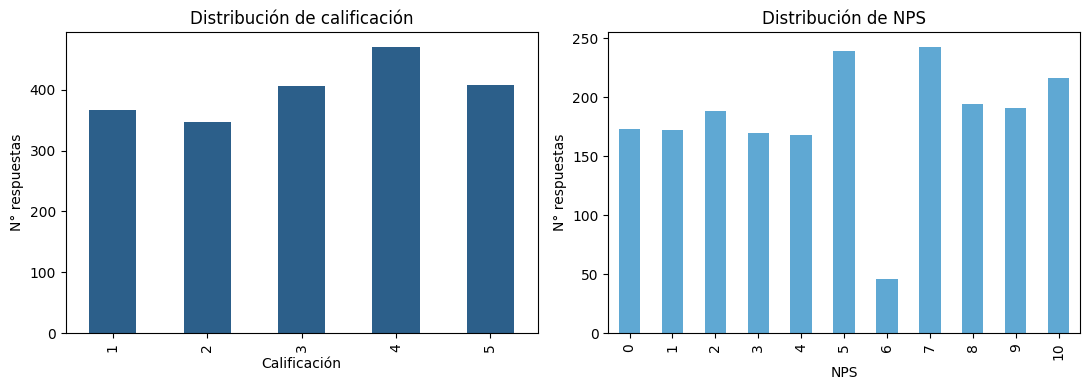

In [2]:

# Distribución de calificaciones y NPS -- contexto cuantitativo antes de entrar al texto
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["calificacion"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2C5F8A")
axes[0].set_title("Distribución de calificación")
axes[0].set_xlabel("Calificación"); axes[0].set_ylabel("N° respuestas")

df["nps"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#5FA8D3")
axes[1].set_title("Distribución de NPS")
axes[1].set_xlabel("NPS"); axes[1].set_ylabel("N° respuestas")
plt.tight_layout()
plt.show()



### 5.2 Preprocesamiento de texto (NLP)

Aplicamos los pasos descritos en la Sección 4.1: normalización, tokenización y remoción de *stopwords* en español. Usamos una lista de stopwords definida manualmente para no depender de una descarga externa (esto hace el notebook reproducible sin conexión a internet).


In [3]:

# Lista de stopwords en español (base compacta; se puede ampliar según el corpus)
STOPWORDS_ES = set("""
a al algo algunas algunos ante antes como con contra cual cuando de del desde donde
durante e el ella ellas ellos en entre era erais eran eras eres es esa esas ese esos
esta estas este esto estos fue fuimos fueron fui ha había habían han has hasta hay
la las le les lo los mas más me mi mis mucho muchos muy nada ni no nos nosotros o os
otra otras otro otros para pero poco por porque que quien quienes se sin sobre su sus
tal también tanto te tenía tener tengo ti tiene tienen todo todos tu tus tuvo un una
uno unos y ya yo mi me muy fue del al este esta esa ese esos esas más pero muy porque
""".split())

def preprocesar(texto: str) -> list:
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_ES and len(t) > 2]
    return tokens

df["tokens"] = df["comentario"].apply(preprocesar)
df["texto_limpio"] = df["tokens"].apply(lambda t: " ".join(t))

print("Ejemplo antes/después de preprocesar:\n")
print("Original:", df.loc[0, "comentario"])
print("Limpio:  ", df.loc[0, "texto_limpio"])


Ejemplo antes/después de preprocesar:

Original: Tuve que cancelar mi pedido porque nunca llegó la confirmación de envío. Además, excelente atención al cliente, me ayudaron de inmediato con mi consulta.
Limpio:   tuve cancelar pedido nunca llegó confirmación envío además excelente atención cliente ayudaron inmediato consulta



### 5.3 Análisis de frecuencias y nube de palabras

Primer acercamiento exploratorio (Sección 4.2). Es rápido, pero recordemos su limitación: no distingue si "entrega" aparece en un contexto positivo ("entrega rápida") o negativo ("demora en la entrega").


In [4]:

from collections import Counter
from wordcloud import WordCloud

todos_los_tokens = [tok for lista in df["tokens"] for tok in lista]
frecuencias = Counter(todos_los_tokens)

print("Top 20 palabras más frecuentes:")
for palabra, count in frecuencias.most_common(20):
    print(f"  {palabra:<15} {count}")


Top 20 palabras más frecuentes:
  producto        449
  llegó           412
  calidad         400
  pedido          368
  además          352
  pena            332
  general         314
  cabe            314
  destacar        314
  vale            308
  tuve            293
  quiero          286
  mencionar       286
  precio          286
  decir           278
  lado            272
  compra          233
  excelente       230
  atención        229
  entrega         189


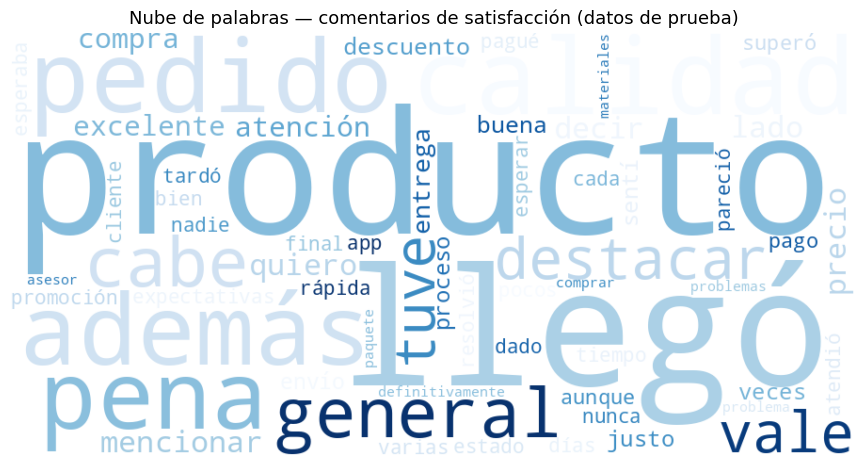

In [5]:

wc = WordCloud(width=900, height=450, background_color="white",
                colormap="Blues", max_words=60).generate_from_frequencies(frecuencias)

plt.figure(figsize=(11, 5.5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — comentarios de satisfacción (datos de prueba)", fontsize=13)
plt.show()



**Lectura crítica de la nube de palabras:** términos como "producto", "entrega" o "atención" aparecen grandes simplemente por ser sustantivos centrales del dominio (retail), no porque indiquen si el sentimiento es positivo o negativo. Esta es exactamente la limitación señalada en la Sección 4.2 — necesitamos técnicas adicionales para capturar polaridad y temas reales.



### 5.4 Análisis de sentimiento basado en léxico (Sección 4.3)

Implementamos el enfoque léxico desde cero, con un diccionario de palabras en español y su polaridad. Es el enfoque más transparente y no requiere conexión a internet ni modelos preentrenados — por eso es reproducible en cualquier entorno.

**Supuesto que debemos declarar explícitamente:** este diccionario es deliberadamente pequeño y simple con fines didácticos. En un caso real de producción se recomienda un léxico más amplio y validado (ej. listas académicas de polaridad en español) o un modelo entrenado en español (ej. `pysentimiento`), que maneja mejor negaciones y contexto.


In [6]:

LEXICO_POSITIVO = {
    "excelente": 3, "excelentes": 3, "bien": 1, "buena": 2, "buen": 2, "bueno": 2,
    "buenos": 2, "rápida": 2, "rápido": 2, "amable": 2, "cordial": 2, "satisfecho": 2,
    "conforme": 1, "puntual": 2, "sencillo": 1, "fácil": 1, "impecable": 3,
    "recomendaría": 2, "recomiendo": 2, "justo": 1, "sorprendido": 1, "eficientes": 2,
    "conveniente": 1, "práctica": 1, "gustó": 2, "vale": 1, "superó": 2,
}

LEXICO_NEGATIVO = {
    "demora": -2, "demoró": -2, "tarde": -2, "lento": -2, "lenta": -2, "defecto": -2,
    "dañado": -2, "roto": -2, "mal": -2, "malo": -2, "mala": -2, "cancelar": -2,
    "reclamar": -2, "reclamo": -2, "confuso": -1, "trabó": -2, "problemas": -2,
    "problema": -2, "deficiente": -3, "cortante": -2, "engorroso": -2, "incompleto": -2,
    "frágil": -2, "excesiva": -2, "excesivo": -2, "nunca": -1,
}

def puntaje_sentimiento(tokens: list) -> int:
    return sum(LEXICO_POSITIVO.get(t, 0) + LEXICO_NEGATIVO.get(t, 0) for t in tokens)

def clasificar_sentimiento(puntaje: int) -> str:
    if puntaje > 0:
        return "positivo"
    elif puntaje < 0:
        return "negativo"
    else:
        return "neutro"

df["puntaje_sentimiento"] = df["tokens"].apply(puntaje_sentimiento)
df["sentimiento_lexico"] = df["puntaje_sentimiento"].apply(clasificar_sentimiento)

df["sentimiento_lexico"].value_counts()


sentimiento_lexico
positivo    1009
negativo     596
neutro       395
Name: count, dtype: int64


#### Validación cruzada: ¿el sentimiento léxico es consistente con `calificacion`?

Esto es exactamente el ejercicio de **triangulación** de la Sección 1.1: comparamos la salida del método cualitativo/computacional contra una variable cuantitativa independiente.


                    calificacion_media  n_comentarios
sentimiento_lexico                                   
negativo                      2.127517            596
neutro                        2.503797            395
positivo                      3.913776           1009


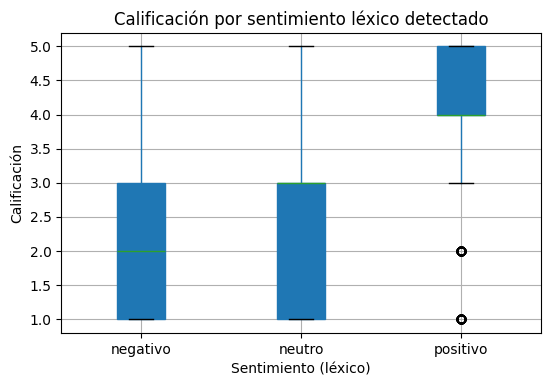

In [7]:

tabla_validacion = df.groupby("sentimiento_lexico")["calificacion"].agg(["mean", "count"])
tabla_validacion.columns = ["calificacion_media", "n_comentarios"]
print(tabla_validacion)

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="calificacion", by="sentimiento_lexico", ax=ax,
           patch_artist=True)
ax.set_title("Calificación por sentimiento léxico detectado")
ax.set_xlabel("Sentimiento (léxico)"); ax.set_ylabel("Calificación")
plt.suptitle("")
plt.show()



**Interpretación esperada:** si el método léxico funciona razonablemente, los comentarios clasificados como "negativo" deberían tener una calificación promedio notablemente menor que los "positivo". Si esto no se observa con claridad, es una señal de que el léxico necesita ajustarse (más palabras, mejor manejo de negaciones) antes de confiar en él para decisiones de negocio — **este tipo de chequeo siempre debe hacerse antes de reportar resultados de sentimiento automatizado.**



### 5.5 Codificación temática deductiva por palabras clave (Sección 2.1 → Análisis de contenido)

Aplicamos un **codebook** predefinido (deductivo) con palabras clave por categoría — el equivalente computacional al análisis de contenido clásico. Un comentario puede recibir más de una categoría (igual que en la codificación manual, donde un comentario puede tocar más de un tema).


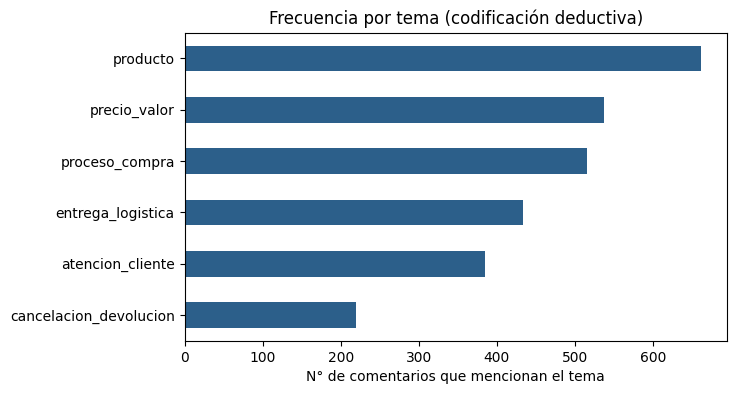


138 comentarios no calzaron con ningún tema del codebook (candidatos a revisar manualmente o a ampliar el codebook).


In [8]:

CODEBOOK = {
    "producto": ["producto", "calidad", "material", "materiales", "defecto",
                 "acabado", "durable", "frágil"],
    "entrega_logistica": ["entrega", "envío", "envio", "demora", "demoró", "paquete",
                           "despacho", "repartidor", "transporte"],
    "atencion_cliente": ["atención", "atencion", "asesor", "servicio", "chat",
                          "personal", "llamada", "tienda"],
    "precio_valor": ["precio", "descuento", "promoción", "promocion", "pagué",
                      "pague", "valor"],
    "proceso_compra": ["compra", "página", "pagina", "app", "pago", "checkout",
                        "plataforma", "cupón", "cupon"],
    "cancelacion_devolucion": ["cancelar", "cancelaron", "devolución", "devolucion",
                                "cambio", "reembolso"],
}

def codificar_deductivo(tokens: list) -> list:
    presentes = set(tokens)
    return [tema for tema, palabras in CODEBOOK.items() if presentes & set(palabras)]

df["temas_codebook"] = df["tokens"].apply(codificar_deductivo)
df["n_temas_codebook"] = df["temas_codebook"].apply(len)

# Frecuencia de cada tema (un comentario puede aportar a varios)
from collections import Counter
conteo_temas = Counter([t for lista in df["temas_codebook"] for t in lista])
pd.Series(conteo_temas).sort_values(ascending=False).plot(
    kind="barh", figsize=(7, 4), color="#2C5F8A", title="Frecuencia por tema (codificación deductiva)"
)
plt.xlabel("N° de comentarios que mencionan el tema")
plt.gca().invert_yaxis()
plt.show()

print(f"\n{(df['n_temas_codebook'] == 0).sum()} comentarios no calzaron con ningún tema del codebook "
      f"(candidatos a revisar manualmente o a ampliar el codebook).")



### 5.6 Modelado de tópicos no supervisado — NMF (Sección 2.2 / 2.3 → Análisis temático inductivo / Teoría fundamentada)

A diferencia de la codificación deductiva anterior (donde nosotros definimos las categorías), aquí dejamos que el algoritmo **descubra** los temas a partir de los patrones de co-ocurrencia de palabras — esto emula la lógica inductiva del análisis temático y la codificación abierta de teoría fundamentada.

Usamos **NMF (Non-negative Matrix Factorization)** sobre una matriz TF-IDF. Es una alternativa a LDA, generalmente más estable con corpus pequeños-medianos como el nuestro (300 documentos).

**Supuesto que debemos declarar:** elegimos `k = 6` tópicos de antemano — el algoritmo no decide este número por sí solo. En un proyecto real, se prueban varios valores de `k` y se evalúa la coherencia/interpretabilidad de los tópicos resultantes.


In [9]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

vectorizador = TfidfVectorizer(max_df=0.85, min_df=3)
X_tfidf = vectorizador.fit_transform(df["texto_limpio"])
vocabulario = vectorizador.get_feature_names_out()

N_TOPICOS = 6
modelo_nmf = NMF(n_components=N_TOPICOS, random_state=42, init="nndsvda", max_iter=500)
W = modelo_nmf.fit_transform(X_tfidf)   # peso de cada documento en cada tópico
H = modelo_nmf.components_               # peso de cada palabra en cada tópico

# Palabras más representativas de cada tópico descubierto
N_PALABRAS = 8
for i, topico in enumerate(H):
    palabras_top = [vocabulario[j] for j in topico.argsort()[-N_PALABRAS:][::-1]]
    print(f"Tópico {i}: {', '.join(palabras_top)}")


Tópico 0: producto, calidad, precio, pareció, justo, considerando, buena, estado
Tópico 1: llegó, pedido, nunca, envío, cancelar, confirmación, tuve, paquete
Tópico 2: pena, decir, vale, atención, excelente, sentí, promoción, aproveché
Tópico 3: compra, proceso, sencillo, intuitivo, web, registrado, sabía, confuso
Tópico 4: tuve, descuento, esperar, tiempo, compensó, problemas, cupón, checkout
Tópico 5: veces, varias, trabó, pagar, momento, página, atendió, resolver


In [10]:

# Asignamos a cada comentario el tópico dominante (mayor peso)
df["topico_nmf"] = W.argmax(axis=1)
df["topico_nmf"].value_counts().sort_index()


topico_nmf
0    422
1    276
2    635
3    246
4    247
5    174
Name: count, dtype: int64


#### Validación: ¿los tópicos descubiertos por NMF recuperan la estructura temática real?

Aquí es donde el carácter **sintético** de nuestro dataset se vuelve útil: como generamos los datos a partir de una estructura temática conocida (`tema_real_sintetico`), podemos verificar objetivamente qué tan bien el modelo no supervisado recuperó esa estructura — algo que **nunca es posible verificar con datos reales**, donde no existe un "answer key".


In [11]:

tabla_cruzada = pd.crosstab(df["tema_real_sintetico"], df["topico_nmf"])
tabla_cruzada


topico_nmf,0,1,2,3,4,5
tema_real_sintetico,,,,,,
atencion_cliente,5,6,106,22,6,27
atencion_cliente_neg,1,4,94,2,18,43
calidad_producto,83,5,65,1,4,3
calidad_producto_neg,111,8,55,8,5,7
cancelacion_devolucion,26,88,10,39,2,4
entrega_logistica,35,51,26,4,37,3
entrega_logistica_neg,1,61,57,29,5,28
neutro_mixto,24,44,65,3,4,3
precio_valor,61,2,45,43,3,2


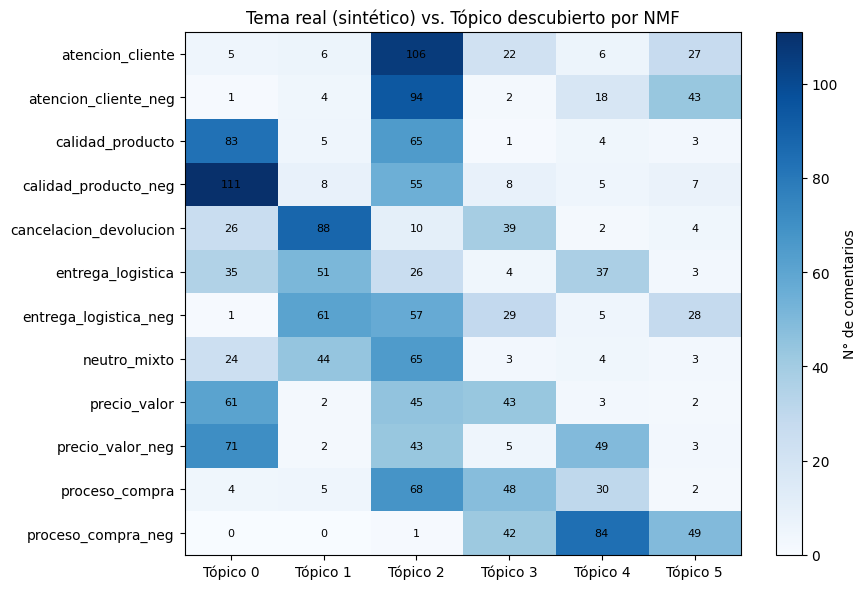

In [12]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(tabla_cruzada.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(tabla_cruzada.shape[1]))
ax.set_xticklabels([f"Tópico {c}" for c in tabla_cruzada.columns])
ax.set_yticks(range(tabla_cruzada.shape[0]))
ax.set_yticklabels(tabla_cruzada.index)
ax.set_title("Tema real (sintético) vs. Tópico descubierto por NMF")
for i in range(tabla_cruzada.shape[0]):
    for j in range(tabla_cruzada.shape[1]):
        ax.text(j, i, tabla_cruzada.values[i, j], ha="center", va="center",
                 color="black", fontsize=8)
plt.colorbar(im, label="N° de comentarios")
plt.tight_layout()
plt.show()



**Cómo leer este resultado:** si el modelo funcionó bien, cada fila (tema real) debería concentrarse mayormente en una sola columna (tópico descubierto), formando un patrón diagonal-like. Si los valores están muy dispersos entre columnas, significa que el modelo no logró separar limpiamente esos temas — típicamente porque son léxicamente similares (ej. "atención" aparece tanto en comentarios positivos como negativos de servicio) o porque `k` no es el número óptimo de tópicos.

**Conclusión metodológica importante:** el modelado de tópicos no supervisado es una **herramienta exploratoria de apoyo**, no un sustituto de la interpretación humana — el analista sigue siendo quien decide si los tópicos encontrados tienen sentido de negocio y cómo nombrarlos, igual que en la fase 5 de Braun & Clarke (Sección 2.2).


### 5.7 IA generativa (LLMs) como asistente de codificación cualitativa

Esta sección tiene **dos rutas**:

**Ruta A — recomendada para clase y sin costo obligatorio:** el notebook construye el prompt con una muestra real del dataset. El estudiante copia ese prompt y lo pega en la versión web disponible de ChatGPT, Gemini o Claude. Después trae la respuesta al análisis y la audita.

**Ruta B — automatización por API (opcional):** en un proyecto institucional puede automatizarse el envío y recepción mediante API, siempre que existan credenciales, presupuesto, políticas de privacidad y autorización para tratar los datos.

**Flujo human-in-the-loop recomendado:**

1. Tomar una muestra de comentarios.
2. Pedir al LLM un `codebook` inicial.
3. Revisar, fusionar o eliminar categorías propuestas.
4. Utilizar el codebook validado para una segunda ronda de clasificación.
5. Auditar manualmente una muestra de clasificaciones.
6. Documentar modelo, fecha, prompt, criterios y desacuerdos.

> Para este curso **no se requiere API de pago**. La automatización es una extensión; el objetivo es aprender a formular, supervisar y validar el análisis.

In [13]:
# RUTA A — gratuita y recomendada para clase:
# construimos el prompt con una muestra y lo copiamos a una IA web.

MUESTRA_PARA_CODEBOOK = df["comentario"].sample(15, random_state=42).tolist()

prompt_codebook = f"""
CONTEXTO
Analizo comentarios de una encuesta de satisfacción de NovaRetail.
Quiero realizar una primera codificación temática exploratoria.

TAREA
1. Propón un codebook de máximo 6 categorías que cubran la muestra.
2. Para cada categoría entrega nombre, definición, criterio de inclusión
   y criterio de exclusión.
3. Señala comentarios ambiguos o que podrían recibir más de un código.
4. No calcules frecuencias del corpus completo: solo estás viendo una muestra.

FORMATO
A. Tabla: categoria | definicion | incluir | excluir.
B. Lista: comentario_ambiguo | razon.
C. Tres preguntas que el analista debería revisar antes de aceptar el codebook.

RESTRICCIONES
- No inventes comentarios, cifras ni causas.
- Trabaja solamente con la muestra entregada.
- No generalices al dataset completo.
- Distingue observación de interpretación.

COMENTARIOS
{chr(10).join(f"- {comentario}" for comentario in MUESTRA_PARA_CODEBOOK)}
"""

print(prompt_codebook)
print("\\n✅ Copia el prompt y ejecútalo en ChatGPT, Gemini o Claude.")


Eres un investigador cualitativo experto en análisis temático (metodología de
Braun & Clarke). A continuación tienes una muestra de comentarios de una
encuesta de satisfacción de una empresa de retail.

Tu tarea:
1. Propone un codebook de máximo 6 categorías temáticas que cubran estos comentarios.
2. Para cada categoría, da un nombre corto, una definición de 1 línea, y 2 palabras
   clave representativas.
3. No inventes comentarios ni frecuencias -- basa el codebook solo en el texto dado.

Comentarios:
- Cabe destacar que El proceso de devolución fue engorroso y tardó demasiado en resolverse.
- Llamé tres veces y cada vez me atendió una persona distinta sin resolver nada.
- Por otro lado, La app se cerró justo cuando iba a confirmar el pago, tuve que repetir todo.
- Cabe destacar que La página se trabó varias veces al momento de pagar.
- Además, El servicio al cliente fue muy lento, nadie respondía mis mensajes.
- También quiero mencionar que La app de NovaRetail es muy práctica para 

#### Auditoría de la respuesta del LLM

Cuando obtengas la respuesta, no preguntes solamente si “suena bien”. Evalúa:

- **Cobertura:** ¿hay experiencias importantes que no quedaron representadas?
- **Exclusividad:** ¿dos categorías significan prácticamente lo mismo?
- **Trazabilidad:** ¿cada categoría puede justificarse con fragmentos reales?
- **Ambigüedad:** ¿el modelo reconoce comentarios mixtos?
- **Estabilidad:** ¿una segunda ejecución produce una estructura muy diferente?
- **Aplicabilidad:** ¿el codebook sirve para responder la pregunta de negocio?

La variación entre modelos o entre ejecuciones es parte de la discusión de clase, no un error que deba esconderse.



**Ejemplo de prompt para clasificación asistida (deductiva) de cada comentario, una vez el codebook ya fue validado por un humano:**


In [14]:

codebook_validado = """
1. producto -- calidad o estado del producto recibido
2. entrega_logistica -- tiempos y condiciones del envío
3. atencion_cliente -- interacción con personal o soporte
4. precio_valor -- percepción de precio, descuentos, relación costo-beneficio
5. proceso_compra -- experiencia en la plataforma/app/checkout
6. cancelacion_devolucion -- cancelaciones, cambios o devoluciones
"""

comentario_ejemplo = df.loc[0, "comentario"]

prompt_clasificacion = f"""
Clasifica el siguiente comentario en una o más de estas categorías del codebook.
Si el comentario menciona más de un tema, indica todos los que apliquen.
No infieras causas ni generalices más allá de lo que dice el texto.

Codebook:
{codebook_validado}

Comentario: "{comentario_ejemplo}"

Responde solo con la lista de categorías aplicables, separadas por coma.
"""

print(prompt_clasificacion)

# response = client.messages.create(
#     model="claude-sonnet-5",
#     max_tokens=100,
#     messages=[{"role": "user", "content": prompt_clasificacion}]
# )
# print(response.content[0].text)



Clasifica el siguiente comentario en una o más de estas categorías del codebook.
Si el comentario menciona más de un tema, indica todos los que apliquen.
No infieras causas ni generalices más allá de lo que dice el texto.

Codebook:

1. producto -- calidad o estado del producto recibido
2. entrega_logistica -- tiempos y condiciones del envío
3. atencion_cliente -- interacción con personal o soporte
4. precio_valor -- percepción de precio, descuentos, relación costo-beneficio
5. proceso_compra -- experiencia en la plataforma/app/checkout
6. cancelacion_devolucion -- cancelaciones, cambios o devoluciones


Comentario: "Tuve que cancelar mi pedido porque nunca llegó la confirmación de envío. Además, excelente atención al cliente, me ayudaron de inmediato con mi consulta."

Responde solo con la lista de categorías aplicables, separadas por coma.




**Supuestos que deben quedar documentados si este flujo se usa en producción:**

- Qué modelo se usó y con qué versión (los resultados pueden cambiar entre versiones de modelo).
- Qué porcentaje de las clasificaciones automáticas fue auditado manualmente y qué tan de acuerdo estuvo el humano con el modelo (esto es el equivalente moderno del *inter-rater reliability*).
- Si los comentarios contienen datos personales, si fueron anonimizados antes de enviarse a la API externa.
- Que el LLM **no debe usarse** para inferir causalidad ("el cliente se queja *porque*...") a menos que el propio texto lo diga explícitamente — el modelo puede alucinar explicaciones plausibles pero no verificadas, igual que un analista humano apurado.



### 5.8 Triangulación final: uniendo todo

Juntamos las tres capas de análisis (sentimiento léxico, codificación deductiva, tópico NMF) con las variables numéricas y de segmentación, para obtener una vista integrada — el objetivo final de cualquier ejercicio de análisis cualitativo aplicado a negocio.


In [15]:

resumen_por_topico = df.groupby("topico_nmf").agg(
    n_comentarios=("comentario", "count"),
    calificacion_media=("calificacion", "mean"),
    nps_medio=("nps", "mean"),
    pct_sentimiento_negativo=("sentimiento_lexico", lambda s: (s == "negativo").mean()),
).round(2)

resumen_por_topico


,n_comentarios,calificacion_media,nps_medio,pct_sentimiento_negativo
topico_nmf,,,,
0,422,3.21,5.49,0.12
1,276,2.86,4.37,0.46
2,635,3.39,5.77,0.26
3,246,3.19,5.43,0.42
4,247,2.76,4.55,0.24
5,174,2.55,3.99,0.51


In [16]:

# Cruce adicional: sentimiento por región y canal (ejemplo de segmentación accionable)
tabla_region = pd.crosstab(df["region"], df["sentimiento_lexico"], normalize="index").round(2)
tabla_region


sentimiento_lexico,negativo,neutro,positivo
region,,,
Andina,0.27,0.23,0.50
Caribe,0.31,0.20,0.49
Orinoquía,0.29,0.18,0.54
Pacífica,0.33,0.19,0.48



---
## 6. Checklist de supuestos y limitaciones — antes de reportar resultados

Antes de llevar cualquiera de estos resultados a una decisión de negocio, verifica:

- [ ] **¿El texto es libre o semi-estructurado?** Si son pocas frases repetidas (como en el ejercicio original de `satisfaccion.csv`), el modelado de tópicos y el clustering semántico aportan poco — basta con un conteo de frecuencias exacto.
- [ ] **¿El léxico de sentimiento fue validado contra la calificación numérica?** (Sección 5.4) Si no hay correspondencia razonable, no reportar el sentimiento como confiable todavía.
- [ ] **¿Se fijó `k` (número de tópicos) de forma arbitraria?** Documentar que fue una decisión del analista, no un resultado "objetivo" del algoritmo.
- [ ] **¿Se auditó una muestra de las clasificaciones automáticas (léxicas, de codebook, o de LLM) contra el criterio humano?**
- [ ] **¿Los datos de texto contienen información personal?** Si se usará una API externa de IA, verificar la política de privacidad/anonimización.
- [ ] **¿Se está afirmando causalidad a partir de un cruce de variables?** Un tema con calificación baja no prueba que ese tema *cause* la insatisfacción — solo que coexisten.
- [ ] **¿El tamaño de muestra es representativo?** Un dataset de 300 comentarios (como este) puede ser suficiente para explorar patrones, pero cualquier generalización a "todos los clientes de NovaRetail" requiere verificar cómo se recolectó la muestra.



## 7. Conclusiones

1. El análisis cualitativo no es una técnica única sino una **familia de metodologías** con distintos supuestos: deductivas (análisis de contenido) vs. inductivas (teoría fundamentada), estructuradas vs. interpretativas.
2. Las herramientas computacionales (frecuencias, sentimiento léxico, topic modeling, LLMs) **aceleran** estas metodologías pero no eliminan la necesidad de **juicio humano** para interpretar, nombrar y validar los resultados.
3. La **triangulación** con variables cuantitativas (`calificacion`, `nps`) es la forma más práctica de auditar si un método cualitativo/computacional está funcionando razonablemente bien.
4. Usar datos **sintéticos con estructura conocida** (como en este notebook) es una técnica valiosa para **validar un pipeline de análisis** antes de aplicarlo a datos reales, donde no existe un "answer key" contra el cual comparar.
5. La IA generativa (LLMs) es prometedora como asistente de codificación, pero su uso responsable exige: revisión humana de muestra, documentación del prompt y modelo usado, y atención a la privacidad de los datos.

---

## 8. Referencias

- Braun, V. & Clarke, V. (2006). *Using thematic analysis in psychology*. Qualitative Research in Psychology, 3(2), 77-101.
- Glaser, B. G. & Strauss, A. L. (1967). *The Discovery of Grounded Theory: Strategies for Qualitative Research*.
- Corbin, J. M. & Strauss, A. (1990). *Grounded theory research: Procedures, canons, and evaluative criteria*. Qualitative Sociology, 13(1), 3-21.
- Eapen, B. R., Archer, N. & Sartipi, K. (2020). *QRMine: A python package for triangulation in Grounded Theory*. arXiv:2003.13519.
- Krippendorff, K. (2018). *Content Analysis: An Introduction to Its Methodology* (4th ed.).
